In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import numpy as np

# locate CSV files produced by ncu
report_dir = os.path.join(r"c:\UT\382V\Nathan\subphase-profiling\experiments\64_token")
csv_files = [os.path.join(report_dir, f) for f in os.listdir(report_dir) if f.endswith('_T.csv')]
csv_files


['c:\\UT\\382V\\Nathan\\subphase-profiling\\experiments\\64_token\\InternVL_LLM_Prefill_T.csv',
 'c:\\UT\\382V\\Nathan\\subphase-profiling\\experiments\\64_token\\InternVL_MLP_Connector_T.csv',
 'c:\\UT\\382V\\Nathan\\subphase-profiling\\experiments\\64_token\\InternVL_Vision_Encoder_T.csv']

Total GPU time for Vision Encoder: 110.34 ms


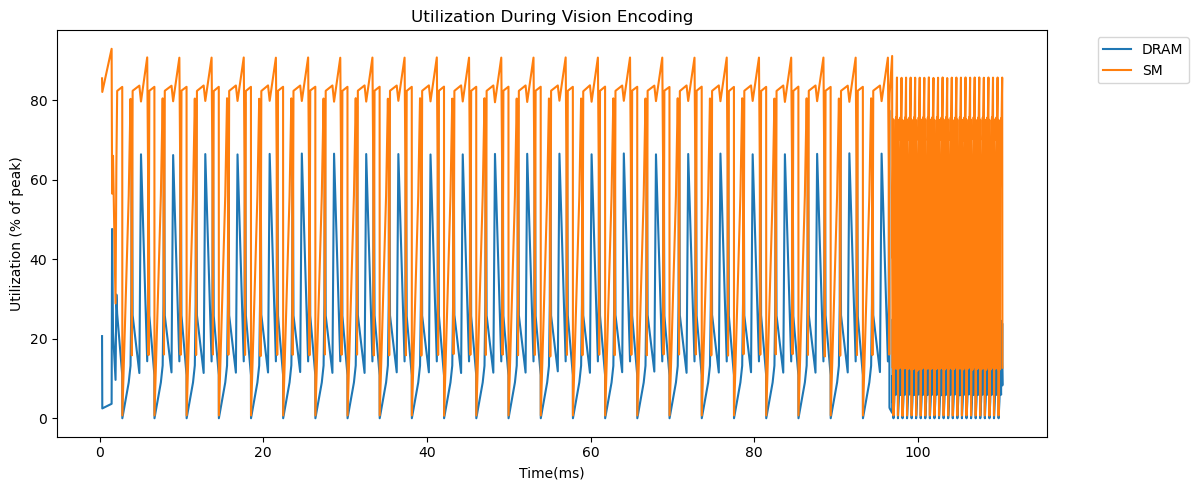

In [100]:
Vision_Encoder_df = pd.read_csv(os.path.join(report_dir, 'InternVL_Vision_Encoder_T.csv'))
Vision_Encoder_df['cumulative_time'] = Vision_Encoder_df['gpu__time_duration.sum [ms]'].cumsum()
Total_time = Vision_Encoder_df['gpu__time_duration.sum [ms]'].sum()
print(f"Total GPU time for Vision Encoder: {Total_time:.2f} ms")
plt.figure(figsize=(12,5))
plt.plot(Vision_Encoder_df['cumulative_time'], Vision_Encoder_df['dram__throughput.avg.pct_of_peak_sustained_elapsed [%]'], label='DRAM')
plt.plot(Vision_Encoder_df['cumulative_time'], Vision_Encoder_df['sm__throughput.avg.pct_of_peak_sustained_active [%]'], label='SM')
plt.xlabel('Time(ms)')
plt.ylabel('Utilization (% of peak)')
plt.title('Utilization During Vision Encoding')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

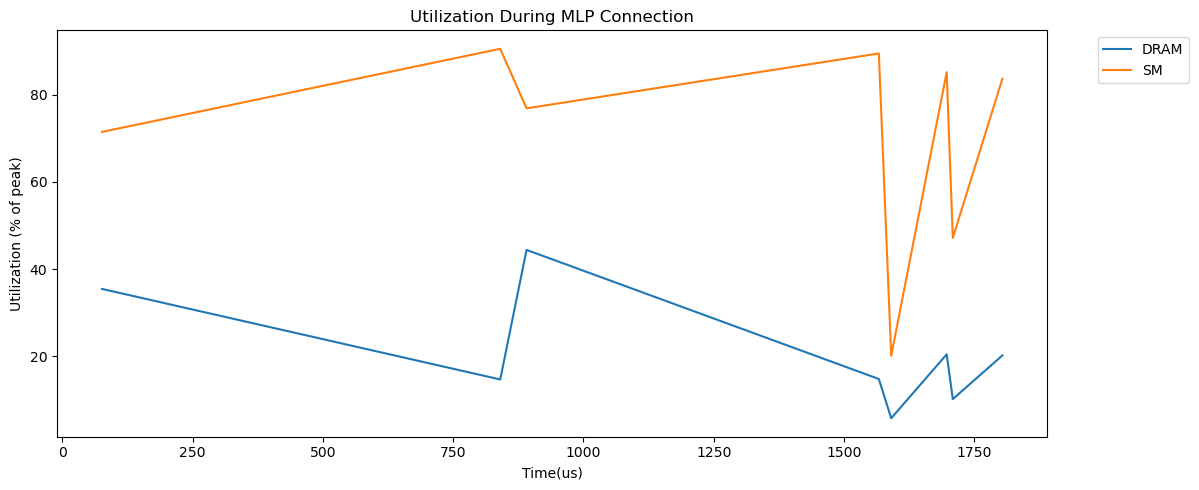

In [81]:
MLP_Connector_df = pd.read_csv(os.path.join(report_dir, 'InternVL_MLP_Connector_T.csv'))
MLP_Connector_df['cumulative_time'] = MLP_Connector_df['gpu__time_duration.sum [us]'].cumsum()
plt.figure(figsize=(12,5))
plt.plot(MLP_Connector_df['cumulative_time'], MLP_Connector_df['dram__throughput.avg.pct_of_peak_sustained_elapsed [%]'], label='DRAM')
plt.plot(MLP_Connector_df['cumulative_time'], MLP_Connector_df['sm__throughput.avg.pct_of_peak_sustained_active [%]'], label='SM')
plt.xlabel('Time(us)')
plt.ylabel('Utilization (% of peak)')
plt.title('Utilization During MLP Connection')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

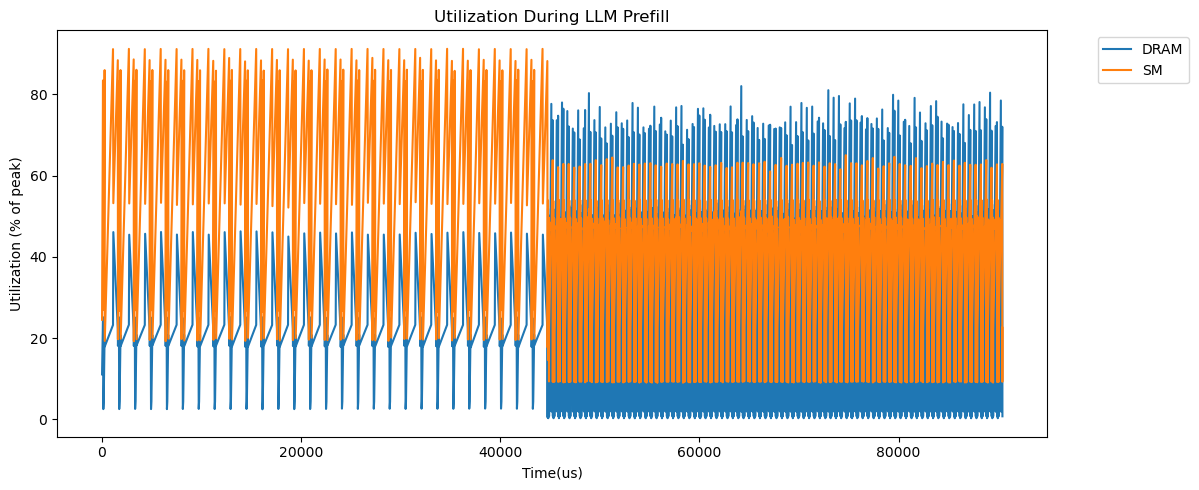

In [82]:
Prefill_df = pd.read_csv(os.path.join(report_dir, 'InternVL_LLM_Prefill_T.csv'))
Prefill_df['cumulative_time'] = Prefill_df['gpu__time_duration.sum [us]'].cumsum()
plt.figure(figsize=(12,5))
plt.plot(Prefill_df['cumulative_time'], Prefill_df['dram__throughput.avg.pct_of_peak_sustained_elapsed [%]'], label='DRAM')
plt.plot(Prefill_df['cumulative_time'], Prefill_df['sm__throughput.avg.pct_of_peak_sustained_active [%]'], label='SM')
plt.xlabel('Time(us)')
plt.ylabel('Utilization (% of peak)')
plt.title('Utilization During LLM Prefill')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

#This is dependent on the size of the image input, I will need to run NCU with the 224x2240 to get a better idea of how this works

In [83]:
import re

def normalize_time_units(df):
    df = df.copy()

    for col in df.columns:
        match = re.search(r"\[(.*?)\]", col)   # find unit inside []
        if not match:
            continue

        unit = match.group(1)

        if unit == "us":
            df[col] = pd.to_numeric(df[col], errors="coerce") / 1000
            new_col = col.replace("[us]", "[ms]")
            df.rename(columns={col: new_col}, inplace=True)

        elif unit == "ns":
            df[col] = pd.to_numeric(df[col], errors="coerce") / 1e6
            new_col = col.replace("[ns]", "[ms]")
            df.rename(columns={col: new_col}, inplace=True)

        elif unit == "ms":
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [ ]:
df1 = pd.read_csv(os.path.join(report_dir, "InternVL_Vision_Encoder_T.csv"), comment="=")
df2 = pd.read_csv(os.path.join(report_dir, "InternVL_MLP_Connector_T.csv"), comment="=")
df3 = pd.read_csv(os.path.join(report_dir, "InternVL_LLM_Prefill_T.csv"), comment="=")

df1["stage"] = "vision_encoder"
df2["stage"] = "mlp_connector"
df3["stage"] = "llm_prefill"

df1 = normalize_time_units(df1)
df2 = normalize_time_units(df2)
df3 = normalize_time_units(df3)

df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
df3.columns = df3.columns.str.strip()

df2 = df2.reindex(columns=df1.columns)
df3 = df3.reindex(columns=df1.columns)

print(df1.shape[0], df2.shape[0], df3.shape[0])

df = pd.concat([df1, df2, df3], ignore_index=True)

df = df.copy()
df.reset_index(drop=True, inplace=True)

df.to_csv("combined_ncu.csv", index=False)


638 8 1292
[np.float64(110.34000000000002), np.float64(112.14397000000002)]


In [ ]:
#df = pd.read_csv(os.path.join(report_dir, 'InternVL_Vision_Encoder_T.csv'))
# Convert relevant columns to numeric
cols = [
    "launch__block_size",
    "launch__waves_per_multiprocessor",
    "sm__maximum_warps_avg_per_active_cycle [warp]",
    "device__attribute_max_warps_per_multiprocessor",
    "sm__throughput.avg.pct_of_peak_sustained_active [%]",
    "dram__throughput.avg.pct_of_peak_sustained_elapsed [%]"
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")


df["warp_occupancy"] = (
    df["sm__maximum_warps_avg_per_active_cycle [warp]"] /
    df["device__attribute_max_warps_per_multiprocessor"]
)

df["compute_util"] = (
    df["sm__throughput.avg.pct_of_peak_sustained_active [%]"] / 100
)

df["memory_util"] = (
    df["dram__throughput.avg.pct_of_peak_sustained_elapsed [%]"] / 100
)


df["wave_efficiency"] = 1 / df["launch__waves_per_multiprocessor"]
df["wave_efficiency"] = df["wave_efficiency"].replace([np.inf, -np.inf], np.nan)

#this is the best estimate I can come up with for overall GPU utilization, since it accounts for both occupancy and compute efficiency.
df["estimated_gpu_util"] = (
    df["warp_occupancy"] *
    df["compute_util"]
)


summary_cols = [
    "warp_occupancy",
    "compute_util",
    "memory_util",
    "launch__waves_per_multiprocessor",
    "wave_efficiency",
    "estimated_gpu_util",
    "gpu__time_duration.sum [ms]",
    "stage"
]

summary = (
    df[summary_cols] 
)

display(summary.head(20))

,warp_occupancy,compute_util,memory_util,launch__waves_per_multiprocessor,wave_efficiency,estimated_gpu_util,gpu__time_duration.sum [ms],sm_idle_fraction,stage
0,1.000,0.8545,0.2068,94.37,0.010597,0.854500,0.28,0.1455,vision_encoder
1,1.000,0.8203,0.0251,8.30,0.120482,0.820300,0.03,0.1797,vision_encoder
2,0.125,0.9287,0.0367,3.85,0.259740,0.116088,1.14,0.0713,vision_encoder
3,1.000,0.5648,0.4760,15.41,0.064893,0.564800,0.06,0.4352,vision_encoder
4,1.000,0.6599,0.2177,15.41,0.064893,0.659900,0.11,0.3401,vision_encoder
5,1.000,0.2889,0.0968,1.00,1.000000,0.288900,0.31,0.7111,vision_encoder
6,1.000,0.6327,0.3112,15.42,0.064851,0.632700,0.10,0.3673,vision_encoder
7,1.000,0.8229,0.2626,7.71,0.129702,0.822900,0.10,0.1771,vision_encoder
8,0.125,0.8330,0.1085,11.67,0.085690,0.104125,0.62,0.1670,vision_encoder
9,1.000,0.0075,0.0004,0.00,NaN,0.007500,0.01,0.9925,vision_encoder


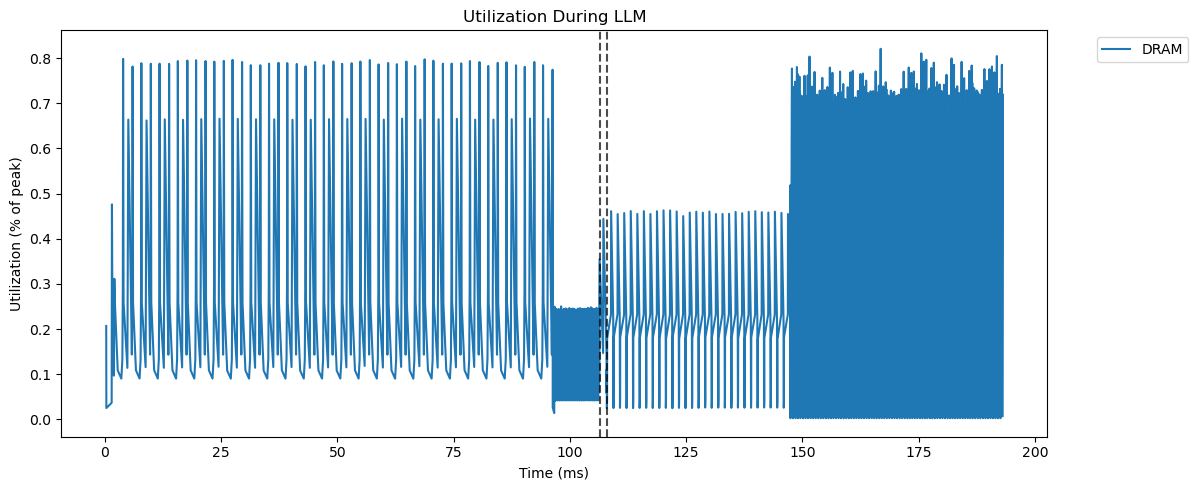

In [120]:
summary = summary.dropna()
summary['cumulative_time'] = summary['gpu__time_duration.sum [ms]'].cumsum()

stage_changes = summary.index[summary["stage"] != summary["stage"].shift()]
boundary_times = summary.loc[stage_changes[1:], "cumulative_time"]

plt.figure(figsize=(12,5))

#plt.plot(summary['cumulative_time'], summary['compute_util'], label='SM')
#plt.plot(summary['cumulative_time'], summary['warp_occupancy'], label='Warp Occupancy')
#plt.plot(summary['cumulative_time'], summary['wave_efficiency'], label='Wave Efficiency')
#plt.plot(summary['cumulative_time'], summary['launch__waves_per_multiprocessor'], label='Launch Waves per Multiprocessor')
plt.plot(summary['cumulative_time'], summary['memory_util'], label='DRAM')
#plt.plot(summary['cumulative_time'], summary['estimated_gpu_util'], label='Estimated GPU Utilization')
#plt.plot(summary['cumulative_time'], summary['sm_idle_fraction'], label='SM Idle')

for t in boundary_times:
    plt.axvline(x=t, linestyle="--", color="black", alpha=0.7)

plt.xlabel('Time (ms)')
plt.ylabel('Utilization (% of peak)')
plt.title('Utilization During LLM')

plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()